<a href="https://colab.research.google.com/github/alyssaplayer/BU_OMDS_APlayerRepo/blob/main/Capstone/DX799_Capstone_OList_(Marketing)_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone Project - Summer Semester OMDS 2026

## Olist Dataset

This notebook focuses on a marketing dataset from the Brazilian e-commerce startup, Olist.

Olist operates with a 'store-within-a-store' model and aims to connect small and medium-sized businesses to major online marketplaces.

The target variable of this analysis is customer satisfaction. When an independent seller on Olist fails to deliver a product on time, the customer leaves a negative review on the marketplace. The goal of the business is to maximise merchant retention and help improve gross merchandise volume. This analysis can isolate which operational, product, and financial variables predict higher customer satistfaction (5) against poor satisfcation (1).

### Target Stakeholders
*   **Primary Audience:** Olist Operations & Logistics Leadership (seeking data-driven ways to reduce delivery delays).
*   **Secondary Audience:** Merchant Success Teams (seeking to coach SMB sellers on optimized product listings).


# Load Required Libraries


In [4]:
import kagglehub
import pandas as pd
import os
import glob
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [5]:
#Loading the Dataset
#Brazilian E-Commerce Public Dataset by Olist
#Kaggle

# Download latest version
path = kagglehub.dataset_download("olistbr/brazilian-ecommerce")

print("Path to dataset files:", path)

df_raw = path

#to save the dataset:
#df.to_csv("olist_df.csv", index=False)

dataset_path = kagglehub.dataset_download("olistbr/brazilian-ecommerce")
print("Dataset downloaded to:", dataset_path)

# List all downloaded CSV files
csv_files = [f for f in os.listdir(dataset_path) if f.endswith('.csv')]
print(f"\nFiles available ({len(csv_files)} CSVs):")
for f in sorted(csv_files):
    print(f"  {f}")

# ── Cell 3: Load each CSV into a named DataFrame ──────────────────────────────
import pandas as pd

orders        = pd.read_csv(os.path.join(dataset_path, "olist_orders_dataset.csv"))
order_items   = pd.read_csv(os.path.join(dataset_path, "olist_order_items_dataset.csv"))
order_reviews = pd.read_csv(os.path.join(dataset_path, "olist_order_reviews_dataset.csv"))
customers     = pd.read_csv(os.path.join(dataset_path, "olist_customers_dataset.csv"))
products      = pd.read_csv(os.path.join(dataset_path, "olist_products_dataset.csv"))
sellers       = pd.read_csv(os.path.join(dataset_path, "olist_sellers_dataset.csv"))
payments      = pd.read_csv(os.path.join(dataset_path, "olist_order_payments_dataset.csv"))
geo           = pd.read_csv(os.path.join(dataset_path, "olist_geolocation_dataset.csv"))
product_names = pd.read_csv(os.path.join(dataset_path, "product_category_name_translation.csv"))

print("All datasets loaded successfully.")

Using Colab cache for faster access to the 'brazilian-ecommerce' dataset.
Path to dataset files: /kaggle/input/brazilian-ecommerce
Using Colab cache for faster access to the 'brazilian-ecommerce' dataset.
Dataset downloaded to: /kaggle/input/brazilian-ecommerce

Files available (9 CSVs):
  olist_customers_dataset.csv
  olist_geolocation_dataset.csv
  olist_order_items_dataset.csv
  olist_order_payments_dataset.csv
  olist_order_reviews_dataset.csv
  olist_orders_dataset.csv
  olist_products_dataset.csv
  olist_sellers_dataset.csv
  product_category_name_translation.csv
All datasets loaded successfully.


In [6]:
#merging all the pertinent datasets in the relational database together
import pandas as pd

# 2. Build the master DataFrame
# Start with orders and add items
df = pd.merge(orders, order_items, on='order_id', how='left')

# Add the review data (adding in the customer satisfaction data)
df = pd.merge(df, order_reviews, on='order_id', how='left')

# Add the customer location/demographic data
df = pd.merge(df, customers, on='customer_id', how='left')

# Check the resulting dataset
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114092 entries, 0 to 114091
Data columns (total 24 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       114092 non-null  object 
 1   customer_id                    114092 non-null  object 
 2   order_status                   114092 non-null  object 
 3   order_purchase_timestamp       114092 non-null  object 
 4   order_approved_at              113930 non-null  object 
 5   order_delivered_carrier_date   112112 non-null  object 
 6   order_delivered_customer_date  110839 non-null  object 
 7   order_estimated_delivery_date  114092 non-null  object 
 8   order_item_id                  113314 non-null  float64
 9   product_id                     113314 non-null  object 
 10  seller_id                      113314 non-null  object 
 11  shipping_limit_date            113314 non-null  object 
 12  price                         

In [7]:
#EDA
display(df.head(), df.describe())



,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1.0,87285b34884572647811a353c7ac498a,...,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1.0,595fac2a385ac33a80bd5114aec74eb8,...,8d5266042046a06655c8db133d120ba5,4.0,Muito boa a loja,Muito bom o produto.,2018-08-08 00:00:00,2018-08-08 18:37:50,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1.0,aa4383b373c6aca5d8797843e5594415,...,e73b67b67587f7644d5bd1a52deb1b01,5.0,NaN,NaN,2018-08-18 00:00:00,2018-08-22 19:07:58,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,1.0,d0b61bfb1de832b15ba9d266ca96e5b0,...,359d03e676b3c069f62cadba8dd3f6e8,5.0,NaN,O produto foi exatamente o que eu esperava e e...,2017-12-03 00:00:00,2017-12-05 19:21:58,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,1.0,65266b2da20d04dbe00c5c2d3bb7859e,...,e50934924e227544ba8246aeb3770dd4,5.0,NaN,NaN,2018-02-17 00:00:00,2018-02-18 13:02:51,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP


,order_item_id,price,freight_value,review_score,customer_zip_code_prefix
count,113314.000000,113314.000000,113314.000000,113131.000000,114092.000000
mean,1.198528,120.478701,19.979428,4.016998,35105.227308
std,0.707016,183.279678,15.783227,1.400074,29868.300916
min,1.000000,0.850000,0.000000,1.000000,1003.000000
25%,1.000000,39.900000,13.080000,4.000000,11250.000000
50%,1.000000,74.900000,16.260000,5.000000,24320.000000
75%,1.000000,134.900000,21.150000,5.000000,59022.000000
max,21.000000,6735.000000,409.680000,5.000000,99990.000000


In [8]:
#EDA - Checking Available Data in the Dataset
# Unique values per column
print("Unique values per column:")
display(df.nunique().to_frame("unique_count"))

# Null values per column
print("\nNull values per column:")
display(df.isnull().sum().to_frame("null_count"))

# Duplicate rows
print(f"\nNumber of duplicate rows: {df.duplicated().sum()}")

Unique values per column:


,unique_count
order_id,99441
customer_id,99441
order_status,8
order_purchase_timestamp,98875
order_approved_at,90733
order_delivered_carrier_date,81018
order_delivered_customer_date,95664
order_estimated_delivery_date,459
order_item_id,21
product_id,32951



Null values per column:


,null_count
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,162
order_delivered_carrier_date,1980
order_delivered_customer_date,3253
order_estimated_delivery_date,0
order_item_id,778
product_id,778



Number of duplicate rows: 0


# EDA Summary
The initial EDA shows that the dataset includes order, customer, and review-level fields. The preview shows the schema and key numeric summaries of each variables. I then checked for unique values, missing values, and duplicates to understand the quality of the data and prepare for feature engineering.

# Feature Engineering


In [9]:
# Date/Time Columns
date_cols = [
    'order_purchase_timestamp', 'order_approved_at',
    'order_delivered_carrier_date', 'order_delivered_customer_date',
    'order_estimated_delivery_date', 'shipping_limit_date',
    'review_creation_date', 'review_answer_timestamp'
]
for col in date_cols:
    df[col] = pd.to_datetime(df[col])

# Numeric Features from Dates
# Days from purchase to actual delivery (satisfaction driver)
df['delivery_days'] = (
    df['order_delivered_customer_date'] - df['order_purchase_timestamp']
).dt.total_seconds() / 86400

#86400 seconds = 1 day

# Early or late dependent on expected delivery date (negative = early, positive = late)
df['delivery_delay_days'] = (
    df['order_delivered_customer_date'] - df['order_estimated_delivery_date']
).dt.total_seconds() / 86400

# Days from purchase to approval
df['approval_days'] = (
    df['order_approved_at'] - df['order_purchase_timestamp']
).dt.total_seconds() / 86400

# How quickly the seller handed to carrier
df['carrier_handoff_days'] = (
    df['order_delivered_carrier_date'] - df['order_approved_at']
).dt.total_seconds() / 86400

# How long the customer waited for a review response
df['review_response_days'] = (
    df['review_answer_timestamp'] - df['review_creation_date']
).dt.total_seconds() / 86400

#  Encode order_status (ordinal — reflects fulfilment progress)
status_order = {
    'created': 0, 'approved': 1, 'processing': 2, 'invoiced': 3,
    'shipped': 4, 'delivered': 5, 'unavailable': -1, 'canceled': -2
}
df['order_status_enc'] = df['order_status'].map(status_order)

# Encode customer_state (frequency encoding — avoids 27 dummies)
state_freq = df['customer_state'].value_counts(normalize=True)
df['customer_state_freq'] = df['customer_state'].map(state_freq)

#  Has review comment? (binary signal)
df['has_comment'] = df['review_comment_message'].notna().astype(int)

#  Drop rows missing the target (review_score)
df_model = df.dropna(subset=['review_score']).copy()

#  Final feature matrix for modelling
feature_cols = [
    'price', 'freight_value', 'order_item_id',
    'delivery_days', 'delivery_delay_days',
    'approval_days', 'carrier_handoff_days', 'review_response_days',
    'order_status_enc', 'customer_state_freq', 'has_comment'
]



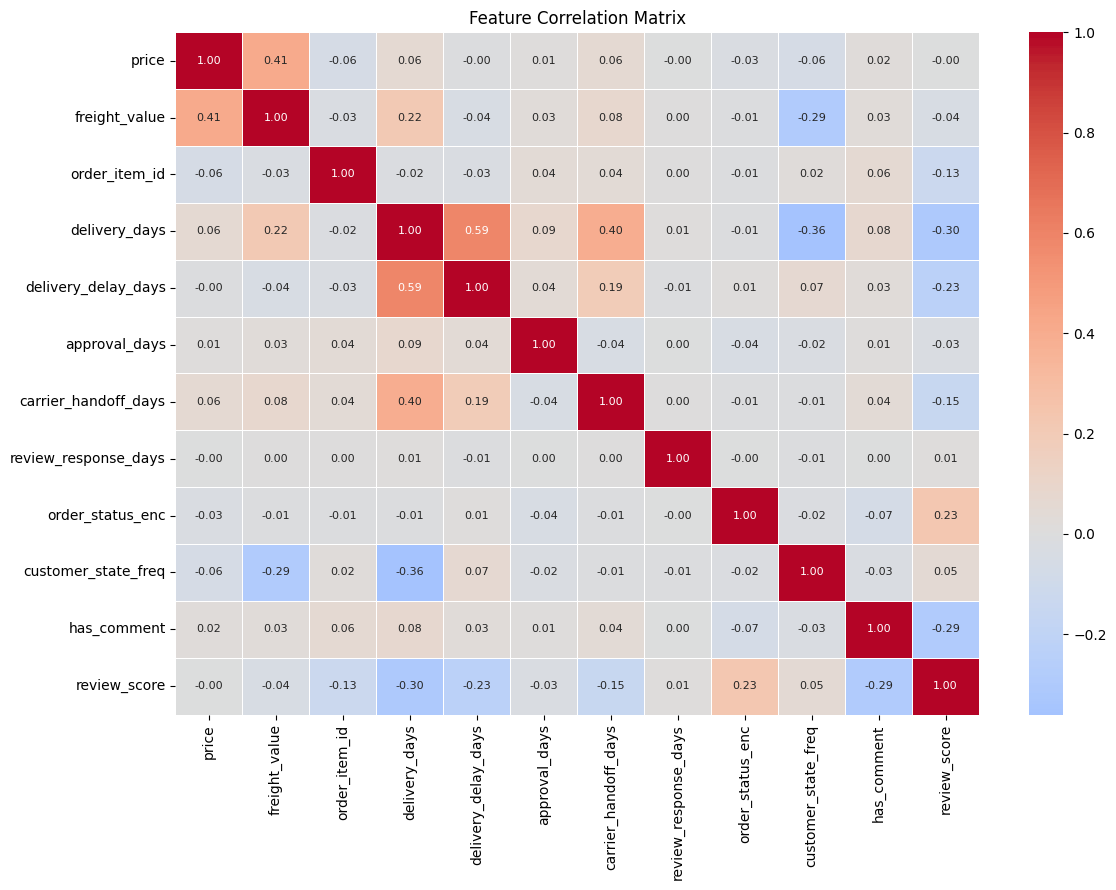

In [10]:
#Correlation Matrix
import seaborn as sns
corr_matrix = df_model[feature_cols + ['review_score']].corr(numeric_only=True)

plt.figure(figsize=(12, 9))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', center=0,
            linewidths=0.5, annot_kws={"size": 8})
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()


### Correlation Matrix Summary
The correlation matrix shows that review_score is most negatively correlated with delivery_days, suggesting that longer delivery times and late deliverers are associated with low customer satisfcation. Furthermore, has_comment and review_score are also negatively correlated (-29), indicating that a customer is more likely to post a comment following a bad experience. There is a positive correlation between order_status_enc and review_score (+23) which could indicate that orders farther long in the ordering pipeline have better review scores. There seems to be redundancy between delivery_days and delivery_delay_days. The strong positive correlation (+59) could be an algorthmic carryover, where delivery_delay_days increase delivery_days. Only one of these should be used moving forward.

### Principal Components

Modelling dataset: 109,996 rows × 11 features
Train: 87,996 rows | Test: 22,000 rows

Target distribution:
review_score
1.0    12578
2.0     3699
3.0     9242
4.0    21179
5.0    63298
Name: count, dtype: int64


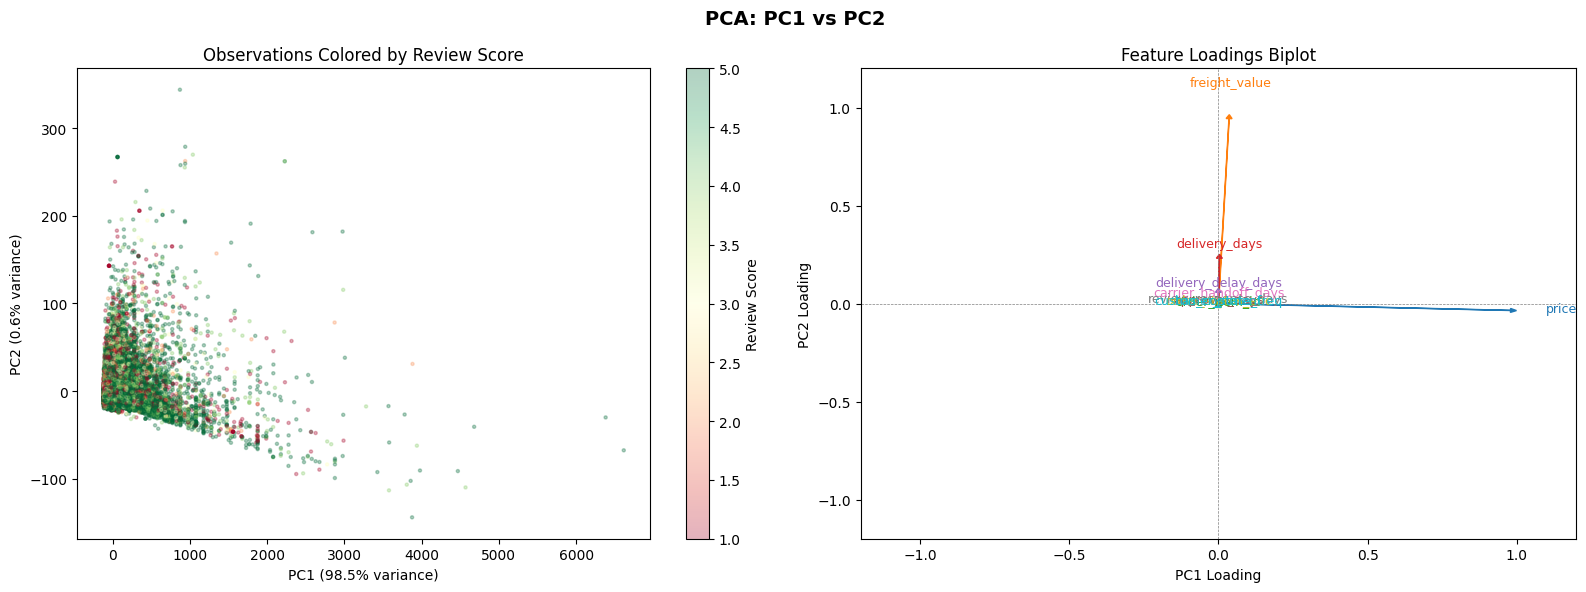

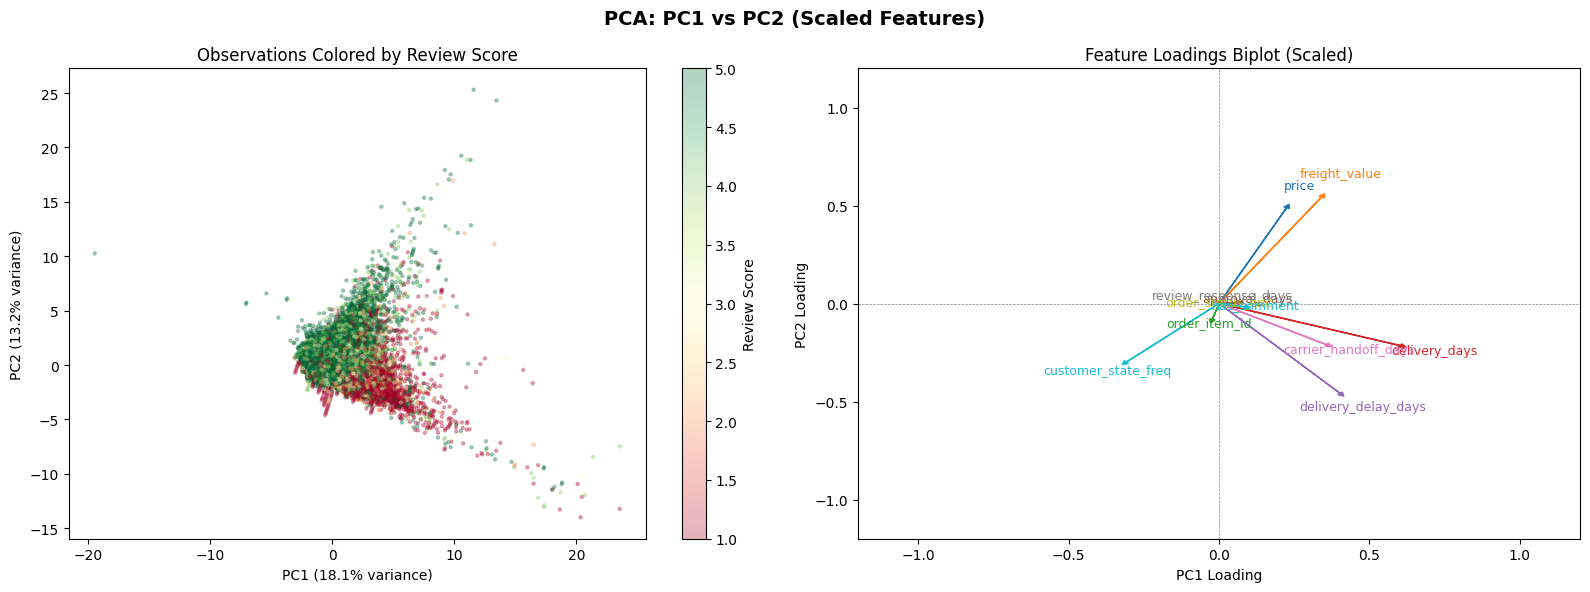

In [15]:
#Train / Test / Split
#Creating a split for testing the data moving forward.
from sklearn.model_selection import train_test_split

df_model = df_model.dropna(subset=feature_cols).copy()

X = df_model[feature_cols]
y = df_model['review_score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Modelling dataset: {X.shape[0]:,} rows × {X.shape[1]} features")
print(f"Train: {X_train.shape[0]:,} rows | Test: {X_test.shape[0]:,} rows")
print(f"\nTarget distribution:\n{y.value_counts().sort_index()}")

from sklearn.decomposition import PCA

# PCA biplot - PC1 vs PC2 with feature loadings
pca_2 = PCA(n_components=2)
X_train_pca = pca_2.fit_transform(X_train)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("PCA: PC1 vs PC2", fontsize=14, fontweight="bold")

# --- Plot 1: Scatter of observations colored by review score ---
scatter = axes[0].scatter(
    X_train_pca[:, 0], X_train_pca[:, 1],
    c=y_train, cmap="RdYlGn", alpha=0.3, s=5
)
plt.colorbar(scatter, ax=axes[0], label="Review Score")
axes[0].set_xlabel(f"PC1 ({pca_2.explained_variance_ratio_[0]*100:.1f}% variance)")
axes[0].set_ylabel(f"PC2 ({pca_2.explained_variance_ratio_[1]*100:.1f}% variance)")
axes[0].set_title("Observations Colored by Review Score")

# --- Plot 2: Feature loadings (biplot arrows) ---
loadings = pca_2.components_.T  # shape: (n_features, 2)
feature_names = X_train.columns

colors = plt.cm.tab10(np.linspace(0, 1, len(feature_names)))

for i, (feature, color) in enumerate(zip(feature_names, colors)):
    axes[1].arrow(0, 0, loadings[i, 0], loadings[i, 1],
                  head_width=0.02, head_length=0.02,
                  fc=color, ec=color, length_includes_head=True)
    axes[1].text(loadings[i, 0] * 1.15, loadings[i, 1] * 1.15,
                 feature, fontsize=9, ha="center", color=color)

axes[1].axhline(0, color="gray", linewidth=0.5, linestyle="--")
axes[1].axvline(0, color="gray", linewidth=0.5, linestyle="--")
axes[1].set_xlabel("PC1 Loading")
axes[1].set_ylabel("PC2 Loading")
axes[1].set_title("Feature Loadings Biplot")
axes[1].set_xlim(-1.2, 1.2)
axes[1].set_ylim(-1.2, 1.2)

plt.tight_layout()
plt.savefig("pca_biplot.png", dpi=150, bbox_inches="tight")
plt.show()



#PC SCALED

from sklearn.preprocessing import StandardScaler

# Scale first
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Fit PCA on scaled data
pca_2 = PCA(n_components=2)
X_train_pca = pca_2.fit_transform(X_train_scaled)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("PCA: PC1 vs PC2 (Scaled Features)", fontsize=14, fontweight="bold")

# --- Plot 1: Scatter of observations colored by review score ---
scatter = axes[0].scatter(
    X_train_pca[:, 0], X_train_pca[:, 1],
    c=y_train, cmap="RdYlGn", alpha=0.3, s=5
)
plt.colorbar(scatter, ax=axes[0], label="Review Score")
axes[0].set_xlabel(f"PC1 ({pca_2.explained_variance_ratio_[0]*100:.1f}% variance)")
axes[0].set_ylabel(f"PC2 ({pca_2.explained_variance_ratio_[1]*100:.1f}% variance)")
axes[0].set_title("Observations Colored by Review Score")

# --- Plot 2: Feature loadings biplot ---
loadings = pca_2.components_.T
feature_names = X_train.columns
colors = plt.cm.tab10(np.linspace(0, 1, len(feature_names)))

for i, (feature, color) in enumerate(zip(feature_names, colors)):
    axes[1].arrow(0, 0, loadings[i, 0], loadings[i, 1],
                  head_width=0.02, head_length=0.02,
                  fc=color, ec=color, length_includes_head=True)
    axes[1].text(loadings[i, 0] * 1.15, loadings[i, 1] * 1.15,
                 feature, fontsize=9, ha="center", color=color)

axes[1].axhline(0, color="gray", linewidth=0.5, linestyle="--")
axes[1].axvline(0, color="gray", linewidth=0.5, linestyle="--")
axes[1].set_xlabel("PC1 Loading")
axes[1].set_ylabel("PC2 Loading")
axes[1].set_title("Feature Loadings Biplot (Scaled)")
axes[1].set_xlim(-1.2, 1.2)
axes[1].set_ylim(-1.2, 1.2)

plt.tight_layout()
plt.savefig("pca_biplot_scaled.png", dpi=150, bbox_inches="tight")
plt.show()

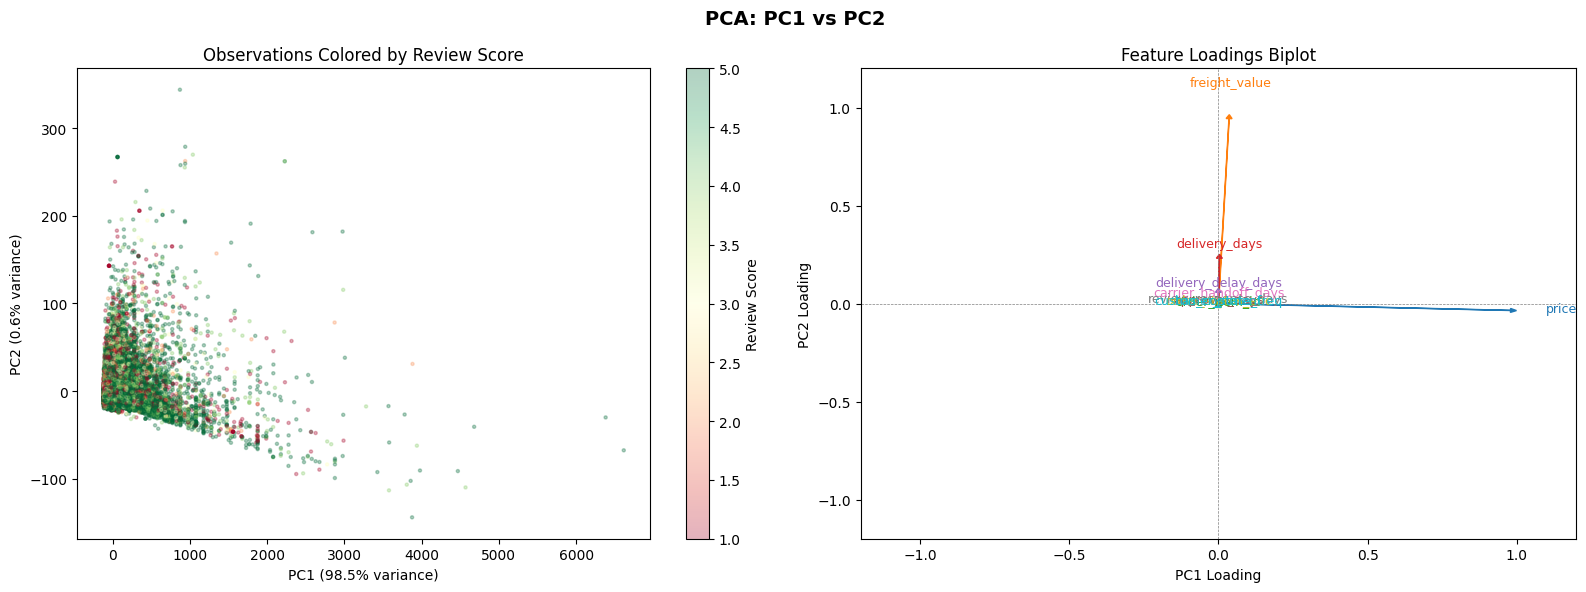

In [16]:
from sklearn.decomposition import PCA

# PCA biplot - PC1 vs PC2 with feature loadings
pca_2 = PCA(n_components=2)
X_train_pca = pca_2.fit_transform(X_train)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("PCA: PC1 vs PC2", fontsize=14, fontweight="bold")

# --- Plot 1: Scatter of observations colored by review score ---
scatter = axes[0].scatter(
    X_train_pca[:, 0], X_train_pca[:, 1],
    c=y_train, cmap="RdYlGn", alpha=0.3, s=5
)
plt.colorbar(scatter, ax=axes[0], label="Review Score")
axes[0].set_xlabel(f"PC1 ({pca_2.explained_variance_ratio_[0]*100:.1f}% variance)")
axes[0].set_ylabel(f"PC2 ({pca_2.explained_variance_ratio_[1]*100:.1f}% variance)")
axes[0].set_title("Observations Colored by Review Score")

# --- Plot 2: Feature loadings (biplot arrows) ---
loadings = pca_2.components_.T  # shape: (n_features, 2)
feature_names = X_train.columns

colors = plt.cm.tab10(np.linspace(0, 1, len(feature_names)))

for i, (feature, color) in enumerate(zip(feature_names, colors)):
    axes[1].arrow(0, 0, loadings[i, 0], loadings[i, 1],
                  head_width=0.02, head_length=0.02,
                  fc=color, ec=color, length_includes_head=True)
    axes[1].text(loadings[i, 0] * 1.15, loadings[i, 1] * 1.15,
                 feature, fontsize=9, ha="center", color=color)

axes[1].axhline(0, color="gray", linewidth=0.5, linestyle="--")
axes[1].axvline(0, color="gray", linewidth=0.5, linestyle="--")
axes[1].set_xlabel("PC1 Loading")
axes[1].set_ylabel("PC2 Loading")
axes[1].set_title("Feature Loadings Biplot")
axes[1].set_xlim(-1.2, 1.2)
axes[1].set_ylim(-1.2, 1.2)

plt.tight_layout()
plt.savefig("pca_biplot.png", dpi=150, bbox_inches="tight")
plt.show()

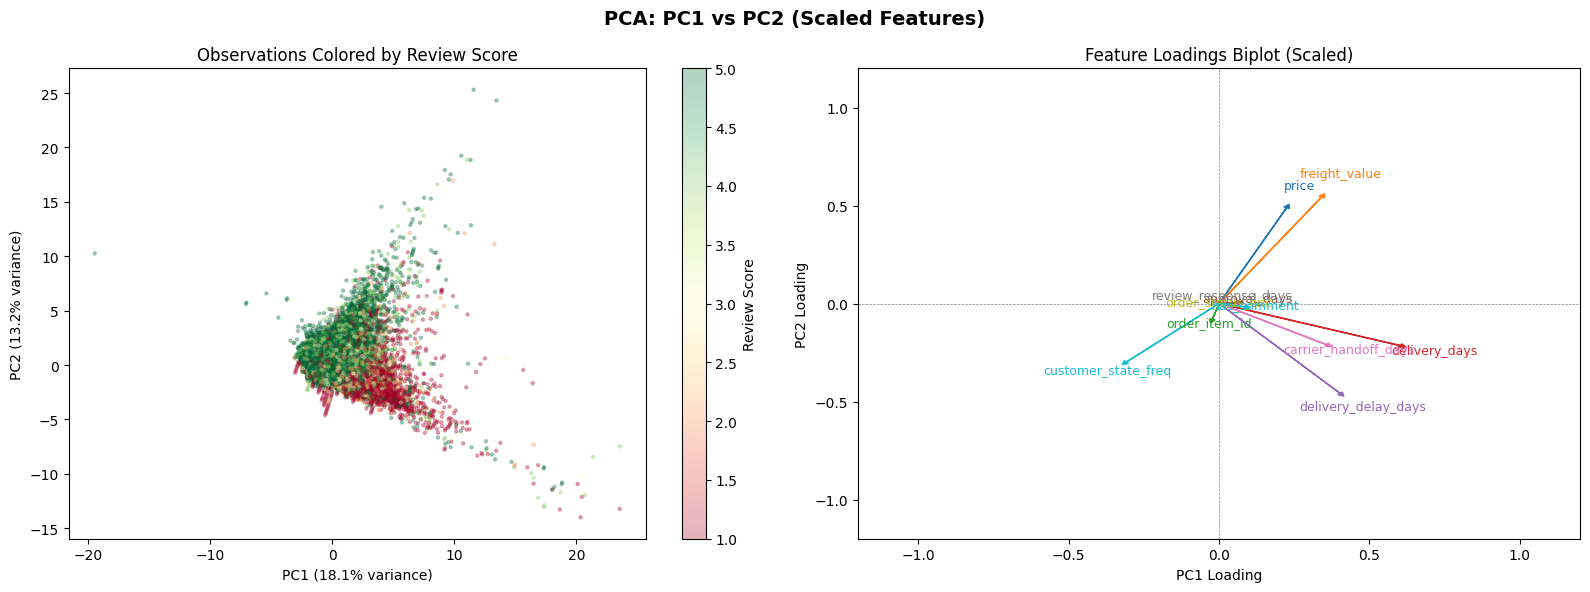

In [17]:
#PC SCALED

from sklearn.preprocessing import StandardScaler

# Scale first
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Fit PCA on scaled data
pca_2 = PCA(n_components=2)
X_train_pca = pca_2.fit_transform(X_train_scaled)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("PCA: PC1 vs PC2 (Scaled Features)", fontsize=14, fontweight="bold")

# --- Plot 1: Scatter of observations colored by review score ---
scatter = axes[0].scatter(
    X_train_pca[:, 0], X_train_pca[:, 1],
    c=y_train, cmap="RdYlGn", alpha=0.3, s=5
)
plt.colorbar(scatter, ax=axes[0], label="Review Score")
axes[0].set_xlabel(f"PC1 ({pca_2.explained_variance_ratio_[0]*100:.1f}% variance)")
axes[0].set_ylabel(f"PC2 ({pca_2.explained_variance_ratio_[1]*100:.1f}% variance)")
axes[0].set_title("Observations Colored by Review Score")

# --- Plot 2: Feature loadings biplot ---
loadings = pca_2.components_.T
feature_names = X_train.columns
colors = plt.cm.tab10(np.linspace(0, 1, len(feature_names)))

for i, (feature, color) in enumerate(zip(feature_names, colors)):
    axes[1].arrow(0, 0, loadings[i, 0], loadings[i, 1],
                  head_width=0.02, head_length=0.02,
                  fc=color, ec=color, length_includes_head=True)
    axes[1].text(loadings[i, 0] * 1.15, loadings[i, 1] * 1.15,
                 feature, fontsize=9, ha="center", color=color)

axes[1].axhline(0, color="gray", linewidth=0.5, linestyle="--")
axes[1].axvline(0, color="gray", linewidth=0.5, linestyle="--")
axes[1].set_xlabel("PC1 Loading")
axes[1].set_ylabel("PC2 Loading")
axes[1].set_title("Feature Loadings Biplot (Scaled)")
axes[1].set_xlim(-1.2, 1.2)
axes[1].set_ylim(-1.2, 1.2)

plt.tight_layout()
plt.savefig("pca_biplot_scaled.png", dpi=150, bbox_inches="tight")
plt.show()

On the raw data, PC1 captures 98.5% of the variance in the features, whereas the PC2 only captures 0.6% variance. The scatter plot shows that price dominates PC1 along the X axis, and freight_value dominates PC2 along the y-axis which indicates that these features have large raw values and should be scaled.

The PCA with scaled features shows that PC1 captures 18.1% variance and PC2 captures 13.2%, which is more balanced than the previous model. Colouring by feature has shown that delivery_days, carrier_handoff_days, and delivery_delay_days are features that move together. Freight_value and price still both positively load onto PC1 and PC2, so high cost orders are clustered. The remaining features are clustered near the origin point which suggests that they don't contribute to the variance amongst the features.

# W1: Linear Regression

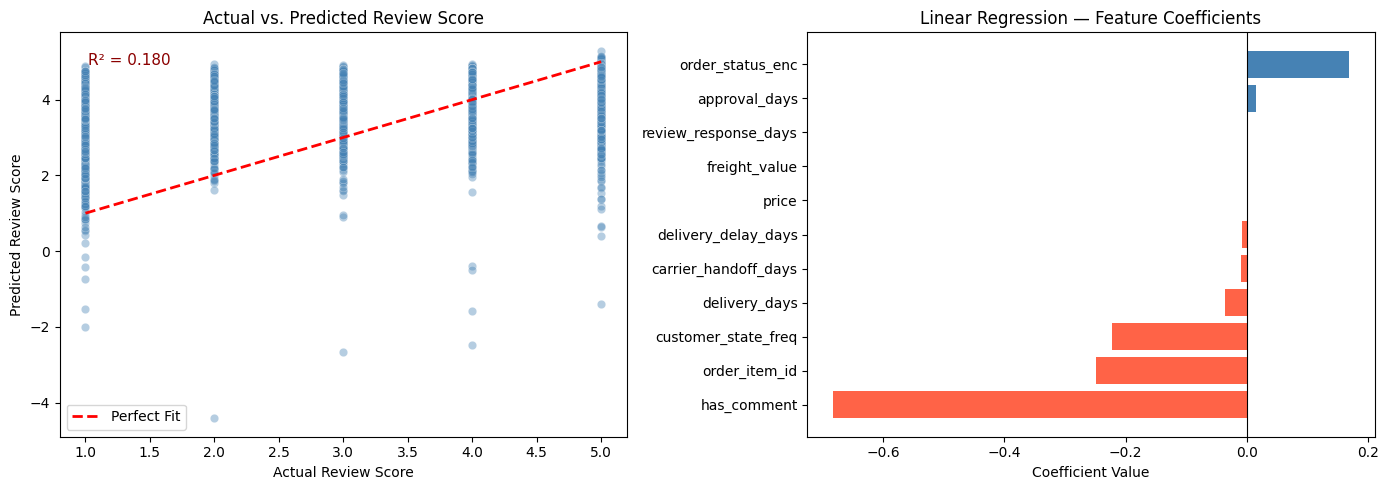

R²:   0.1797
RMSE: 1.2134


In [18]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Actual vs Predicted
axes[0].scatter(y_test, y_pred, alpha=0.4, color='steelblue', edgecolors='white', linewidth=0.3)
axes[0].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()], 'r--', linewidth=2, label='Perfect Fit')
axes[0].set_xlabel('Actual Review Score')
axes[0].set_ylabel('Predicted Review Score')
axes[0].set_title('Actual vs. Predicted Review Score')
axes[0].legend()
axes[0].annotate(f'R² = {r2_score(y_test, y_pred):.3f}',
                 xy=(0.05, 0.92), xycoords='axes fraction', fontsize=11, color='darkred')

# Feature coefficients
coef_df = pd.Series(model.coef_, index=feature_cols).sort_values()
axes[1].barh(coef_df.index, coef_df.values, color=['tomato' if v < 0 else 'steelblue' for v in coef_df.values])
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Linear Regression — Feature Coefficients')
axes[1].set_xlabel('Coefficient Value')

plt.tight_layout()
plt.show()

print(f"R²:   {r2_score(y_test, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")

# Week 2: Lasso, Ridge, and Elastic Net Regression

In [19]:
#Lasso Regression
import sklearn
from sklearn.linear_model import Lasso

# Initialize the model (alpha acts as the lambda regularization parameter)
# By default, alpha=1.0
lasso_model = Lasso(alpha=1.0)

# Fit the model to your training data
lasso_model.fit(X_train, y_train)

# Make predictions
predictions = lasso_model.predict(X_test)

In [20]:
#Ridge Regression
from sklearn.linear_model import Ridge

# Initialize the model
# By default, alpha=1.0
ridge_model = Ridge(alpha=1.0)

# Fit the model to your training data
ridge_model.fit(X_train, y_train)

# Make predictions
predictions = ridge_model.predict(X_test)

#use GridSearch CV to test lambda

In [21]:
#Elastic Net Regression
from sklearn.linear_model import ElasticNet

# Initialize the model
# alpha controls the overall strength of the penalty
# l1_ratio controls the mix (l1_ratio=1.0 is pure Lasso, 0.0 is pure Ridge)
# Default l1_ratio is generally 0.5 (an even split)
elastic_net_model = ElasticNet(alpha=1.0, l1_ratio=0.5)

# Fit the model to your training data
elastic_net_model.fit(X_train, y_train)

# Make predictions
predictions = elastic_net_model.predict(X_test)

In [22]:
from sklearn.metrics import r2_score, mean_squared_error

for name, m in [("Lasso", lasso_model), ("Ridge", ridge_model), ("ElasticNet", elastic_net_model)]:
    preds = m.predict(X_test)
    print(f"{name:12s} | R²: {r2_score(y_test, preds):.4f} | RMSE: {np.sqrt(mean_squared_error(y_test, preds)):.4f}")

import pandas as pd

coef_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Lasso": lasso_model.coef_,
    "Ridge": ridge_model.coef_,
    "ElasticNet": elastic_net_model.coef_
})

print(coef_df.sort_values("Ridge", ascending=False).to_string(index=False))

Lasso        | R²: 0.0873 | RMSE: 1.2799
Ridge        | R²: 0.1797 | RMSE: 1.2134
ElasticNet   | R²: 0.0933 | RMSE: 1.2758
             Feature     Lasso     Ridge  ElasticNet
    order_status_enc  0.000000  0.167568    0.000000
       approval_days -0.000000  0.014871    0.000000
review_response_days  0.000000  0.001391    0.000000
       freight_value  0.000000  0.000849    0.000000
               price  0.000093  0.000087    0.000119
 delivery_delay_days -0.004074 -0.009000   -0.006861
carrier_handoff_days -0.000000 -0.010669   -0.000000
       delivery_days -0.029935 -0.035902   -0.033639
 customer_state_freq -0.000000 -0.222131   -0.000000
       order_item_id -0.000000 -0.249154   -0.000000
         has_comment -0.000000 -0.682503   -0.000000


### Linear Regression Summary

Lasso Regression yielded the lowest R^2 score, but high mean squared error.


The regularised regression models, Lasso, Ridge, and ElasticNet, were trained to predict customer review scores from order and logistics features. Ridge performed best and explains approximately 18% of variance in review scores (R² = 0.18, RMSE = 1.21), whereas Lasso and ElasticNet only explained around 9%. The lower R² implies that logistics and order features alone capture only a portion of what drives customer satisfaction.


The strongest predictor across models was has_comment, a binary indicator of whether the customer left a written review. Its negative coefficient suggests that customers who wrote comments tended to leave lower scores, consistent with the behavioral tendency for dissatisfied customers to provide written feedback. Delivery-related features — particularly delivery_days and delivery_delay_days — also negatively predicted review scores, confirming that longer or delayed deliveries are associated with lower ratings. Lasso zeroed out most features, retaining only delivery time, delivery delay, and price, while Ridge retained all features with small but nonzero coefficients.

# W3: Forward / Backward Selection, PCR, and PLSR

In [23]:
#Forward and Backward Selection
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from mlxtend.feature_selection import SequentialFeatureSelector as SFS

lr = LinearRegression()

# Forward Selection
forward_selector = SFS(
    lr,
    k_features="best",
    forward=True,
    floating=False,
    scoring="r2",
    cv=5
)
forward_selector.fit(X_train, y_train)
print("Forward Selection Features:", forward_selector.k_feature_names_)

# Backward Selection
backward_selector = SFS(
    lr,
    k_features="best",
    forward=False,
    floating=False,
    scoring="r2",
    cv=5
)
backward_selector.fit(X_train, y_train)
print("Backward Selection Features:", backward_selector.k_feature_names_)

Forward Selection Features: ('price', 'freight_value', 'order_item_id', 'delivery_days', 'delivery_delay_days', 'approval_days', 'carrier_handoff_days', 'review_response_days', 'order_status_enc', 'customer_state_freq', 'has_comment')
Backward Selection Features: ('price', 'freight_value', 'order_item_id', 'delivery_days', 'delivery_delay_days', 'approval_days', 'carrier_handoff_days', 'review_response_days', 'order_status_enc', 'customer_state_freq', 'has_comment')


Both selection models retained the full feature set with agreement in the same order, which implies that no feature was negative impacting the model performance.

In [24]:
#PCR and PLSR
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
import numpy as np

# Principal Component Regression (PCR)
pcr_pipeline = Pipeline([
    ("pca", PCA(n_components=5)),
    ("lr", LinearRegression())
])
pcr_pipeline.fit(X_train, y_train)
pcr_preds = pcr_pipeline.predict(X_test)
print(f"PCR     | R²: {r2_score(y_test, pcr_preds):.4f} | RMSE: {np.sqrt(mean_squared_error(y_test, pcr_preds)):.4f}")

# Partial Least Squares Regression (PLSR)
plsr_model = PLSRegression(n_components=5)
plsr_model.fit(X_train, y_train)
plsr_preds = plsr_model.predict(X_test)
print(f"PLSR    | R²: {r2_score(y_test, plsr_preds):.4f} | RMSE: {np.sqrt(mean_squared_error(y_test, plsr_preds)):.4f}")

PCR     | R²: 0.0968 | RMSE: 1.2733
PLSR    | R²: 0.1797 | RMSE: 1.2134


### Summary of W3/W4 Findings  
Lasso        | R²: 0.0873 | RMSE: 1.2799
Ridge        | R²: 0.1797 | RMSE: 1.2134
ElasticNet   | R²: 0.0933 | RMSE: 1.2758

PCR     | R²: 0.0968 | RMSE: 1.2733
PLSR    | R²: 0.1797 | RMSE: 1.2134

Ridge and PLSR are the best performing models, with methods converging around R^2 = 0.18. PCR underperformed the other models which could be due to it's  Lasso remained the worst performing model.

#W4: Logistic regression and feature scaling

In [ ]:
#logistic regression and feature scaling

#W5: Support Vector Machines

In [ ]:
#Support vector machines, the kernel trick, and regularization for support vector machines

###W6: Decision Trees and Random Forests